# RIPE Atlas — can these findings be measured independently?

The M-Lab exports show the path to whichever server a school's client happened
to choose. That is a real limit: every conclusion in
`meter_traceroutes_07.ipynb` describes routes to one or two vantage points, not
to the internet in general, and there is no way to ask the data a new question.

RIPE Atlas is the natural extension, because a probe can be pointed at any
target on demand. It only works where Atlas has a probe **in the network under
study** — and this notebook checks whether it does, before any measurement is
planned.

**Questions answered**
- **Q1** — how many probes does the country have, and how many are alive?
- **Q2** — do they sit in the networks that actually carry school traffic?
- **Q3** — how does that look across all 28 countries?

Probe discovery needs no API key; only creating measurements does. The approach
follows `atlas_dns_content_geography.ipynb`, which submits measurements once a
probe set is fixed.

---
## Part 0 — Configuration

In [1]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import sys
import json
import logging
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, 'helpers')
from atlas_probes import (fetch_probes, probe_inventory,
                          coverage_against_schools, coverage_summary)
from load_traceroutes import load_traceroutes

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
from giga_chart_style import *

pd.set_option('display.width', 200)

COUNTRY_ISO2 = "NA"          # <- country to check; NA = Namibia
_ref = json.load(open('helpers/country_reference.json'))
COUNTRY_NAME = next((v['name'] for v in _ref.values()
                     if v['iso2'] == COUNTRY_ISO2), COUNTRY_ISO2)
print(f"{COUNTRY_NAME} ({COUNTRY_ISO2})")

Namibia (NA)


---
## Q1 — How many probes, and how many are alive?

Atlas reports every probe ever registered, most of which are no longer
connected. A probe that is abandoned or disconnected cannot be measured from,
however long it ran, so the registered count overstates what is available —
usually by a lot.

In [2]:
# =============================================================================
# Q1 — PROBE INVENTORY
# =============================================================================
inventory = probe_inventory(COUNTRY_ISO2)

print(f"Probes ever registered: {len(inventory)}")
print(f"Currently connected   : {int(inventory['connected'].sum())}")
print(f"Anchors               : {int(inventory['is_anchor'].sum())}   "
      "(anchors are hosted, better connected and more stable than home probes)\n")

display(inventory['status'].value_counts().rename('probes').to_frame())
display(inventory[inventory['connected']]
        [['probe_id', 'asn_v4', 'prefix_v4', 'is_anchor', 'tags']])

Probes ever registered: 15
Currently connected   : 3
Anchors               : 0   (anchors are hosted, better connected and more stable than home probes)



,probes
status,
Abandoned,9
Connected,3
Written Off,1
Never Connected,1
Disconnected,1


,probe_id,asn_v4,prefix_v4,is_anchor,tags
1,12385,33763.0,41.218.90.0/23,False,"nat, system-ipv4-capable, system-ipv4-rfc1918,..."
4,12803,37009.0,41.63.192.0/18,False,"fibre, system-ipv4-capable, system-ipv4-rfc191..."
14,1000327,33763.0,41.218.92.0/22,False,"home, system-ipv4-capable, system-ipv4-rfc1918..."


---
## Q2 — Are the probes in the networks that carry school traffic?

The count is not the question. A country can hold dozens of probes and still
have none in the operator that serves most of its schools, which leaves the
finding unverifiable no matter how many probes are nominally available.

Each network carrying school traceroutes is joined to the probes living inside
it, weighted by how much of the country's school traffic that network carries.

In [3]:
# =============================================================================
# Q2 — COVERAGE AGAINST THE NETWORKS SCHOOLS ACTUALLY USE
# =============================================================================
tr = load_traceroutes(COUNTRY_ISO2)
coverage = coverage_against_schools(COUNTRY_ISO2, inventory, traceroutes=tr)
display(coverage)

_s = coverage_summary(coverage)
print(f"School-serving networks           : {_s['school_asns']}")
print(f"   ...with a live probe inside    : {_s['asns_with_live_probe']}")
print(f"Share of school traffic reachable : {_s['traces_measurable_pct']}%\n")
print(f"Largest network: {_s['largest_asn']} carries {_s['largest_asn_pct']}% "
      f"of traces — measurable: {_s['largest_asn_measurable']}")

if not _s['largest_asn_measurable']:
    print("\nThe operator carrying most of this country's school traffic has no "
          "live probe.\nAtlas cannot independently reproduce or extend a finding "
          "about that network,\nwhatever the country-level probe count suggests.")

,src_asn,src_asn_name,traces,trace_pct,probes_registered,probes_connected,measurable
0,36996,Telecom Namibia,37900,93.2,5,0,False
1,33763,Internet Technologies Namibia,1481,3.6,4,2,True
2,37009,"MTC - Mobile Telecommunications, Ltd.",1282,3.2,2,1,True
3,36999,Telecom Namibia,15,0.0,0,0,False


School-serving networks           : 4
   ...with a live probe inside    : 2
Share of school traffic reachable : 6.8%

Largest network: Telecom Namibia carries 93.2% of traces — measurable: False

The operator carrying most of this country's school traffic has no live probe.
Atlas cannot independently reproduce or extend a finding about that network,
whatever the country-level probe count suggests.


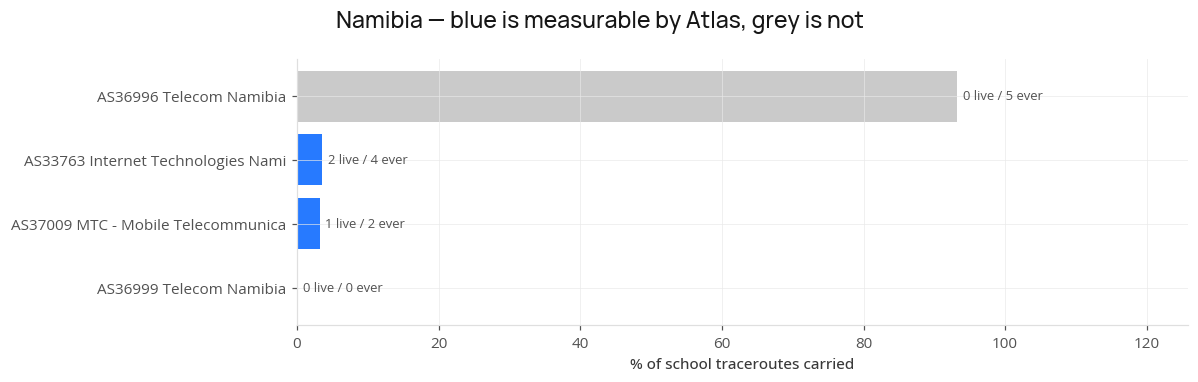

In [4]:
# =============================================================================
# Q2b — WHERE THE TRAFFIC IS AGAINST WHERE THE PROBES ARE
# =============================================================================
_top = coverage.head(8).iloc[::-1]
_labels = [f"AS{int(r.src_asn)} {str(r.src_asn_name)[:26]}" for r in _top.itertuples()]

fig, ax = plt.subplots(figsize=(11, max(3, 0.5 * len(_top) + 1.5)))
_colors = [GIGA_BLUE if m else GIGA_GREY[400] for m in _top['measurable']]
ax.barh(_labels, _top['trace_pct'], color=_colors)
for _i, r in enumerate(_top.itertuples()):
    ax.text(r.trace_pct + 0.8, _i,
            f"{r.probes_connected} live / {r.probes_registered} ever",
            va='center', fontsize=8.5, color=GIGA_GREY[700])
ax.set_xlabel('% of school traceroutes carried')
ax.set_xlim(0, max(100, _top['trace_pct'].max() * 1.35))
fig.suptitle(f'{COUNTRY_NAME} — blue is measurable by Atlas, grey is not')
plt.tight_layout(); plt.show()

---
## Q3 — The same question across every country

Whether Atlas can extend a finding is a property of the country, and it varies
enormously. `data/traceroutes/atlas_coverage.csv` holds the scan; the ordering
below is what decides where an Atlas follow-up is worth planning.

In [5]:
# =============================================================================
# Q3 — CROSS-COUNTRY COVERAGE
# =============================================================================
scan = pd.read_csv('data/traceroutes/atlas_coverage.csv')
scan = scan[scan['traces'].notna()].sort_values('traces_measurable_pct')
display(scan[['country', 'traces', 'probes_registered', 'probes_connected',
              'anchors', 'asns_with_live_probe', 'traces_measurable_pct',
              'largest_asn_measurable']])

_blind = int((~scan['largest_asn_measurable'].astype(bool)).sum())
print(f"Countries where the largest school ISP has no live probe: {_blind} of {len(scan)}")
print(f"Countries with no connected probe at all                : "
      f"{int((scan['probes_connected'] == 0).sum())}")

,country,traces,probes_registered,probes_connected,anchors,asns_with_live_probe,traces_measurable_pct,largest_asn_measurable
22,Rwanda,5268,24,1,1,0,0.0,False
2,Benin,810,87,8,0,0,0.0,False
3,Botswana,21650,7,1,0,0,0.0,False
4,Belize,13993,24,0,0,0,0.0,False
5,Congo (Brazzaville),105,28,3,0,0,0.0,False
6,Dominica,1529,1,0,0,0,0.0,False
7,Fiji,75146,19,1,0,0,0.0,False
8,Grenada,136,4,0,0,0,0.0,False
16,Lesotho,1678,5,1,0,0,0.0,False
20,Malawi,28211,14,1,0,0,0.0,False


Countries where the largest school ISP has no live probe: 18 of 28
Countries with no connected probe at all                : 4


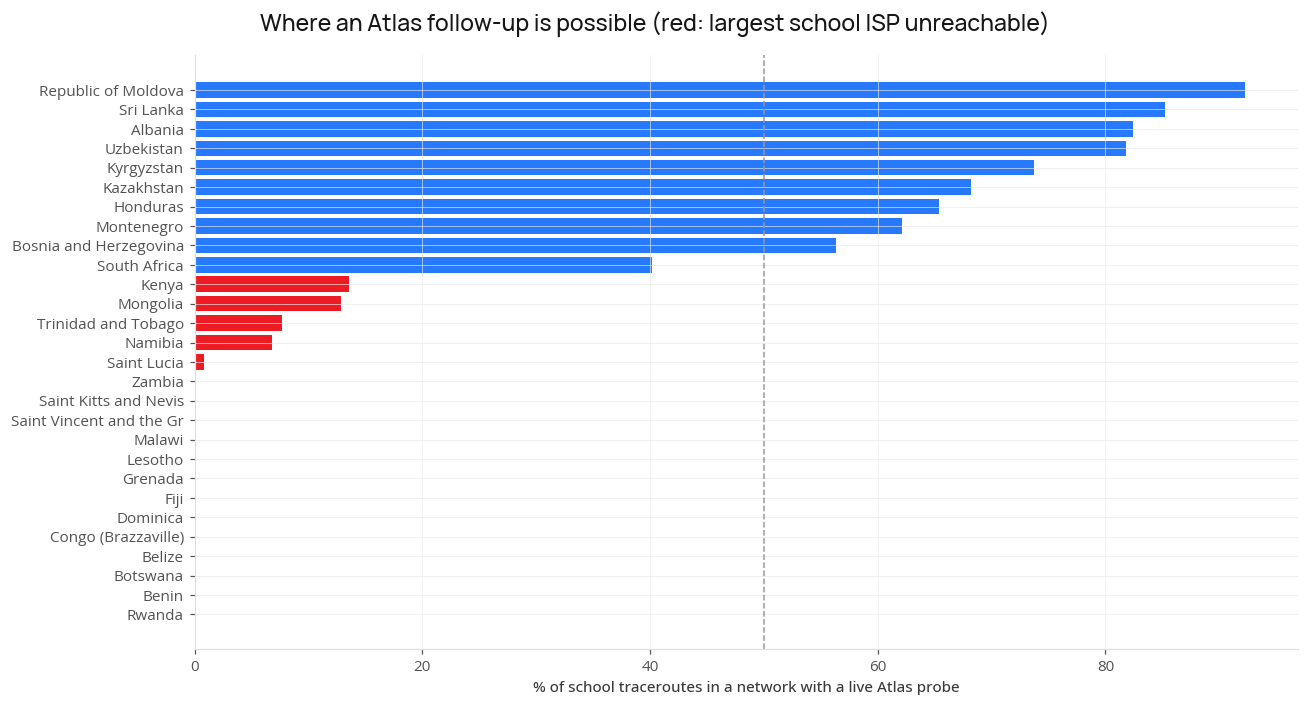

The countries with the sharpest traceroute findings are largely the ones
Atlas cannot reach: Malawi, Fiji and Belize sit at 0%, Namibia at 6.8%.
Albania, Moldova and Sri Lanka are the findings that could be extended
with independent measurement.


In [6]:
# =============================================================================
# Q3b — COVERAGE AGAINST THE FINDINGS THAT NEED IT
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6.5))
_s = scan.sort_values('traces_measurable_pct')
_colors = [GIGA_BLUE if m else GIGA_BAD for m in _s['largest_asn_measurable'].astype(bool)]
ax.barh(_s['country'], _s['traces_measurable_pct'], color=_colors)
ax.set_xlabel('% of school traceroutes in a network with a live Atlas probe')
ax.axvline(50, color=GIGA_GREY[500], linestyle='--', linewidth=1)
fig.suptitle('Where an Atlas follow-up is possible (red: largest school ISP unreachable)')
plt.tight_layout(); plt.show()

print("The countries with the sharpest traceroute findings are largely the ones")
print("Atlas cannot reach: Malawi, Fiji and Belize sit at 0%, Namibia at 6.8%.")
print("Albania, Moldova and Sri Lanka are the findings that could be extended")
print("with independent measurement.")

---
## What this means for a follow-up

**Independent measurement is thinnest where connectivity is worst.** That is
not a coincidence to work around — it is a finding in its own right, and it
bounds what any of this analysis can claim. A route that cannot be probed
cannot be re-tested when it changes, cannot be compared against a different
destination, and cannot be verified by anyone else.

Three consequences for the case studies:

* **Namibia** — the strongest natural experiment in the dataset, and the
  operator carrying 93% of its school traffic has five registered probes, all
  abandoned. The finding stands on the M-Lab data alone and cannot currently be
  extended or independently confirmed.
* **Albania, Moldova, Sri Lanka** — 82-92% of school traffic sits in networks
  with live probes. An Atlas follow-up here could test routes toward
  destinations schools actually use, rather than only toward an M-Lab server.
* **Belize, Dominica, Grenada, Saint Vincent** — no connected probe at all.

Where a follow-up is viable, `atlas_dns_content_geography.ipynb` carries the
measurement submission, parsing and IXP enrichment; this notebook only settles
whether the probe set exists to submit from.